# Các thư viện sử dụng

In [1]:
import os
import cv2
import dlib
import time
import random
import math
import numpy as np
import seaborn as sns
import urllib.request
import matplotlib.pyplot as plt

# Thư viện cho HOG và Machine Learning 
from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, precision_recall_curve
from sklearn.model_selection import train_test_split

# Thư viện cho Deep Learning (CNN)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

# =====================================================================
# TẢI VÀ KHỞI TẠO MÔ HÌNH DEEP LEARNING (DNN) CỦA OPENCV
prototxt_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt"
caffemodel_url = "https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel"

prototxt_path = "deploy.prototxt"
caffemodel_path = "res10_300x300_ssd_iter_140000.caffemodel"

# Tự động tải file từ Github của OpenCV nếu máy chưa có
if not os.path.exists(prototxt_path):
    print("Đang tải deploy.prototxt...")
    urllib.request.urlretrieve(prototxt_url, prototxt_path)
if not os.path.exists(caffemodel_path):
    print("Đang tải res10_300x300_ssd_iter_140000.caffemodel...")
    urllib.request.urlretrieve(caffemodel_url, caffemodel_path)

# Load mạng DNN vào bộ nhớ (Khai báo 1 lần để dùng cho toàn bộ file)
dnn_net = cv2.dnn.readNetFromCaffe(prototxt_path, caffemodel_path)
print("Đã tải và khởi tạo thành công mạng DNN Face Detector!")
# =====================================================================

# Cấu hình đường dẫn
DATASET_PATH = '/kaggle/input/datasets/omkargurav/face-mask-dataset/data'
mask_dir = os.path.join(DATASET_PATH, 'with_mask')
nomask_dir = os.path.join(DATASET_PATH, 'without_mask')

# Lấy toàn bộ tên file trong thư mục
mask_files = os.listdir(mask_dir)
nomask_files = os.listdir(nomask_dir)

# Bốc ngẫu nhiên 1 tên file
random_mask_name = random.choice(mask_files)
random_nomask_name = random.choice(nomask_files)

# Đọc ảnh
sample_img_mask = cv2.imread(os.path.join(mask_dir, random_mask_name))
sample_img_nomask = cv2.imread(os.path.join(nomask_dir, random_nomask_name))

print("Đã load thư viện và ảnh mẫu thành công!")

2026-05-24 02:22:35.969591: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779589356.223430      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779589356.285426      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779589356.941681      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779589356.941752      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779589356.941755      16 computation_placer.cc:177] computation placer alr

Đang tải deploy.prototxt...
Đang tải res10_300x300_ssd_iter_140000.caffemodel...
Đã tải và khởi tạo thành công mạng DNN Face Detector!
Đã load thư viện và ảnh mẫu thành công!


In [2]:
def show_images(images, titles, cols=2, cmap=None, is_bgr=True):
    rows = math.ceil(len(images) / cols)
    
    # Điều chỉnh kích thước khung hình cho cân đối
    plt.figure(figsize=(cols * 4, rows * 4))
    
    for i in range(len(images)):
        plt.subplot(rows, cols, i + 1)
        img = images[i]
        
        # Nhận diện ảnh xám (2 chiều)
        if len(img.shape) == 2:
            plt.imshow(img, cmap='gray' if cmap is None else cmap)
        
        # Nhận diện ảnh màu (3 chiều)
        else:
            if is_bgr:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.imshow(img)
            
        plt.title(titles[i])
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# Tiền xử lý ảnh

In [3]:
def custom_preprocess(resized_bgr):
    gray = cv2.cvtColor(resized_bgr, cv2.COLOR_BGR2GRAY)
    filtered = cv2.bilateralFilter(gray, 5, 75, 75)
    return filtered

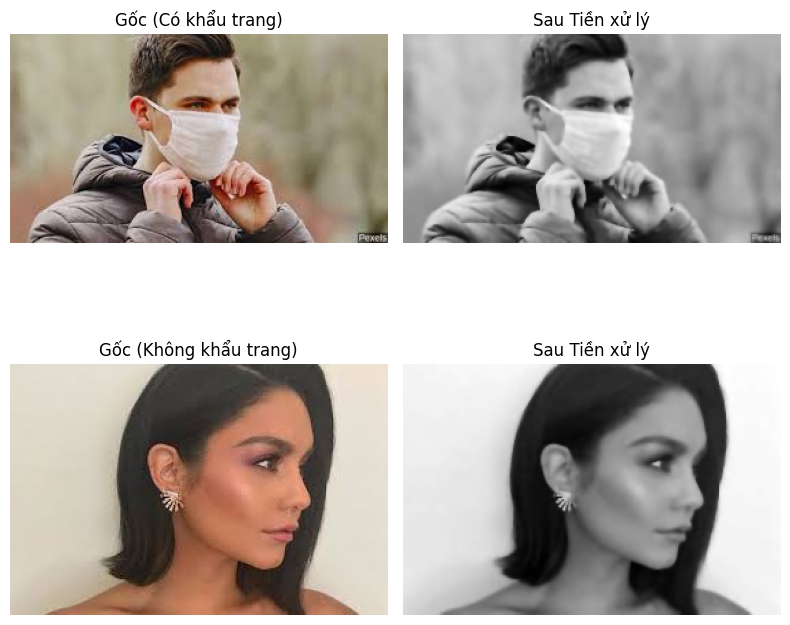

In [4]:
processed_mask = custom_preprocess(sample_img_mask)
processed_nomask = custom_preprocess(sample_img_nomask)

imgs = [sample_img_mask, processed_mask, sample_img_nomask, processed_nomask]
titles = ["Gốc (Có khẩu trang)", "Sau Tiền xử lý", "Gốc (Không khẩu trang)", "Sau Tiền xử lý"]

show_images(imgs, titles, cols=2)

# Phát hiện khuôn mặt

## Sliding Window + Image Pyramid (Thông qua thư viện dlib)

In [5]:
hog_face_detector = dlib.get_frontal_face_detector()

def detect_face_hog(img_bgr, padding_ratio=0.15): 
    # 1. dlib cũng cần ảnh xám để tối ưu tốc độ
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    # 2. Phát hiện khuôn mặt (tham số 1 là số lần upsample ảnh, để 0 cho nhanh)
    faces = hog_face_detector(gray, 0)
    
    h_img, w_img = img_bgr.shape[:2]
    
    # Cơ chế Fallback: Không thấy mặt thì trả về toàn bộ ảnh
    if len(faces) == 0:
        return (0, 0, w_img, h_img)
    
    # 3. Lấy khuôn mặt lớn nhất (nếu có nhiều mặt)
    # dlib trả về object hình chữ nhật, ta lấy diện tích bằng width() * height()
    largest_face = max(faces, key=lambda rect: rect.width() * rect.height())
    
    # Lấy tọa độ (x, y, w, h) từ object của dlib
    x = largest_face.left()
    y = largest_face.top()
    w = largest_face.width()
    h = largest_face.height()
    
    # 4. Áp dụng Padding 
    pad_w = int(w * padding_ratio)
    pad_h = int(h * padding_ratio)
    
    new_x = max(0, x - pad_w)
    new_y = max(0, y - pad_h)
    new_w = min(w_img - new_x, w + 2*pad_w)
    new_h = min(h_img - new_y, h + 2*pad_h)
    
    return (new_x, new_y, new_w, new_h)

Kích thước ảnh 1: Rộng 301, Cao 167 | Tọa độ Dlib: (115, 19, 93, 93)
Kích thước ảnh 2: Rộng 275, Cao 183 | Tọa độ Dlib: (131, 27, 135, 135)


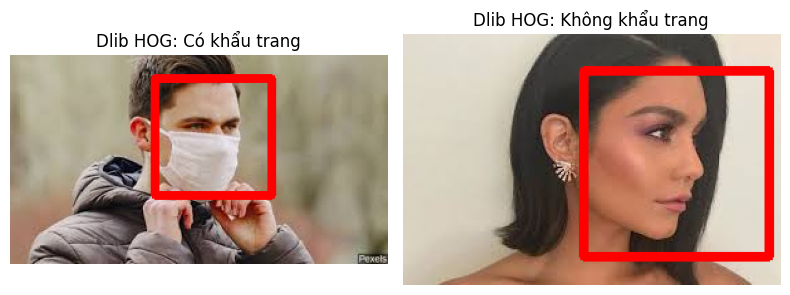

In [6]:
# 1. Gọi hàm Dlib HOG để lấy tọa độ
bbox_mask_hog = detect_face_hog(sample_img_mask)
bbox_nomask_hog = detect_face_hog(sample_img_nomask)

# 2. In tọa độ ra để kiểm tra (rất quan trọng để biết thuật toán có bị Fallback không)
h1, w1 = sample_img_mask.shape[:2]
h2, w2 = sample_img_nomask.shape[:2]

print(f"Kích thước ảnh 1: Rộng {w1}, Cao {h1} | Tọa độ Dlib: {bbox_mask_hog}")
print(f"Kích thước ảnh 2: Rộng {w2}, Cao {h2} | Tọa độ Dlib: {bbox_nomask_hog}")

# 3. Vẽ Bounding Box (Màu Đỏ, độ dày = 6 để dễ nhìn)
img_show_1_hog = sample_img_mask.copy()
cv2.rectangle(img_show_1_hog, 
              (bbox_mask_hog[0], bbox_mask_hog[1]), 
              (bbox_mask_hog[0] + bbox_mask_hog[2], bbox_mask_hog[1] + bbox_mask_hog[3]), 
              (0, 0, 255), 6) 

img_show_2_hog = sample_img_nomask.copy()
cv2.rectangle(img_show_2_hog, 
              (bbox_nomask_hog[0], bbox_nomask_hog[1]), 
              (bbox_nomask_hog[0] + bbox_nomask_hog[2], bbox_nomask_hog[1] + bbox_nomask_hog[3]), 
              (0, 0, 255), 6)

# 4. Sử dụng hàm show_images của bạn để hiển thị
imgs = [img_show_1_hog, img_show_2_hog]
titles = ["Dlib HOG: Có khẩu trang", "Dlib HOG: Không khẩu trang"]

# Gọi hàm của bạn (mặc định is_bgr=True nên nó sẽ tự chuyển màu cho đúng)
show_images(imgs, titles, cols=2)

## Mô hình Deep Neural Network (DNN)

In [7]:
def detect_face_dnn(img_bgr, conf_threshold=0.5, padding_ratio=0.15):
    h_img, w_img = img_bgr.shape[:2]
    
    # Tiền xử lý ảnh theo chuẩn đầu vào của mạng SSD (Resize về 300x300, trừ Mean Value)
    blob = cv2.dnn.blobFromImage(cv2.resize(img_bgr, (300, 300)), 1.0, 
                                 (300, 300), (104.0, 177.0, 123.0))
    
    dnn_net.setInput(blob)
    detections = dnn_net.forward()
    
    best_conf = 0
    best_box = None
    
    # Lặp qua các bounding box dự đoán để tìm khuôn mặt có độ tự tin cao nhất
    for i in range(0, detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        
        # Chỉ lấy khuôn mặt vượt ngưỡng (mặc định > 50%)
        if confidence > conf_threshold and confidence > best_conf:
            best_conf = confidence
            
            # Trích xuất tọa độ Bounding Box 
            box = detections[0, 0, i, 3:7] * np.array([w_img, h_img, w_img, h_img])
            (startX, startY, endX, endY) = box.astype("int")
            
            w = endX - startX
            h = endY - startY
            best_box = (startX, startY, w, h)
            
    # Cơ chế Fallback
    if best_box is None:
        return (0, 0, w_img, h_img)
        
    x, y, w, h = best_box
    
    # Tính toán lại khung hình dựa trên padding_ratio
    pad_w = int(w * padding_ratio)
    pad_h = int(h * padding_ratio)
    
    new_x = max(0, x - pad_w)
    new_y = max(0, y - pad_h)
    new_w = min(w_img - new_x, w + 2*pad_w)
    new_h = min(h_img - new_y, h + 2*pad_h)
    
    return (new_x, new_y, new_w, new_h)

Tọa độ DNN - Có khẩu trang: (np.int64(107), np.int64(7), np.int64(87), np.int64(115))
Tọa độ DNN - Không khẩu trang: (np.int64(115), 0, np.int64(122), np.int64(170))


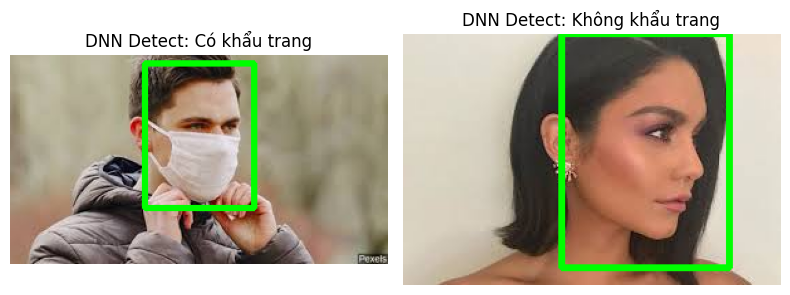

In [8]:
# 1. Gọi hàm DNN để lấy tọa độ Bounding Box
bbox_mask_dnn = detect_face_dnn(sample_img_mask)
bbox_nomask_dnn = detect_face_dnn(sample_img_nomask)

# 2. In tọa độ ra để kiểm tra chéo (chứng minh code không bị Fallback)
print(f"Tọa độ DNN - Có khẩu trang: {bbox_mask_dnn}")
print(f"Tọa độ DNN - Không khẩu trang: {bbox_nomask_dnn}")

# 3. Vẽ Bounding Box (Khung màu xanh lá, nét dày 4px)
img_show_1_dnn = sample_img_mask.copy()
cv2.rectangle(img_show_1_dnn, 
              (bbox_mask_dnn[0], bbox_mask_dnn[1]), 
              (bbox_mask_dnn[0] + bbox_mask_dnn[2], bbox_mask_dnn[1] + bbox_mask_dnn[3]), 
              (0, 255, 0), 4) 

img_show_2_dnn = sample_img_nomask.copy()
cv2.rectangle(img_show_2_dnn, 
              (bbox_nomask_dnn[0], bbox_nomask_dnn[1]), 
              (bbox_nomask_dnn[0] + bbox_nomask_dnn[2], bbox_nomask_dnn[1] + bbox_nomask_dnn[3]), 
              (0, 255, 0), 4)

# 4. Hiển thị bằng hàm show_images của bạn
imgs = [img_show_1_dnn, img_show_2_dnn]
titles = ["DNN Detect: Có khẩu trang", "DNN Detect: Không khẩu trang"]

show_images(imgs, titles, cols=2)

## So sánh

In [9]:
num_test_each = 100
test_mask_filenames = mask_files[:num_test_each]
test_nomask_filenames = nomask_files[:num_test_each]

all_images = []
all_labels = []

# Đọc ảnh có khẩu trang
for filename in test_mask_filenames:
    img_path = os.path.join(mask_dir, filename)
    img = cv2.imread(img_path)
    if img is not None:
        all_images.append(img)
        all_labels.append("mask")

# Đọc ảnh không khẩu trang
for filename in test_nomask_filenames:
    img_path = os.path.join(nomask_dir, filename)
    img = cv2.imread(img_path)
    if img is not None:
        all_images.append(img)
        all_labels.append("nomask")

print(f"Đã đọc thành công {len(all_images)} ảnh")

Đã đọc thành công 200 ảnh


In [10]:
def run_benchmark(images, labels):
    print("Đang tiến hành quét khuôn mặt bằng OpenCV DNN và Dlib HOG.")
    
    dnn_times, hog_times = [], []
    dnn_detect_mask, dnn_detect_nomask = 0, 0
    hog_detect_mask, hog_detect_nomask = 0, 0
    
    for i, img in enumerate(images):
        label = labels[i]
        
        # --- Chạy OpenCV DNN ---
        start_t = time.time()
        nx, ny, nw, nh = detect_face_dnn(img)  # Gọi hàm DNN
        dnn_times.append(time.time() - start_t)
        
        # Kiểm tra Fallback: Nếu không trả về toàn bộ ảnh tức là tìm thấy mặt
        if nw > 0 and nh > 0 and (nw != img.shape[1] or nh != img.shape[0]): 
            if label == "mask": dnn_detect_mask += 1
            else: dnn_detect_nomask += 1
                
        # --- Chạy Dlib HOG ---
        start_t = time.time()
        dx, dy, dw, dh = detect_face_hog(img) # Gọi hàm Dlib
        hog_times.append(time.time() - start_t)
        
        # Kiểm tra Fallback
        if dw > 0 and dh > 0 and (dw != img.shape[1] or dh != img.shape[0]):
            if label == "mask": hog_detect_mask += 1
            else: hog_detect_nomask += 1

    # Tính toán FPS
    avg_dnn_ms = np.mean(dnn_times) * 1000
    avg_hog_ms = np.mean(hog_times) * 1000
    
    fps_dnn = 1000 / avg_dnn_ms
    fps_hog = 1000 / avg_hog_ms
    
    # Tính tỷ lệ Recall trên ảnh CÓ KHẨU TRANG
    actual_mask_count = labels.count("mask")
    acc_dnn_mask = (dnn_detect_mask / actual_mask_count) * 100
    acc_hog_mask = (hog_detect_mask / actual_mask_count) * 100
    
    print("HOÀN THÀNH BENCHMARK!")
    return (fps_dnn, fps_hog), (acc_dnn_mask, acc_hog_mask)

Đang tiến hành quét khuôn mặt bằng OpenCV DNN và Dlib HOG.
HOÀN THÀNH BENCHMARK!


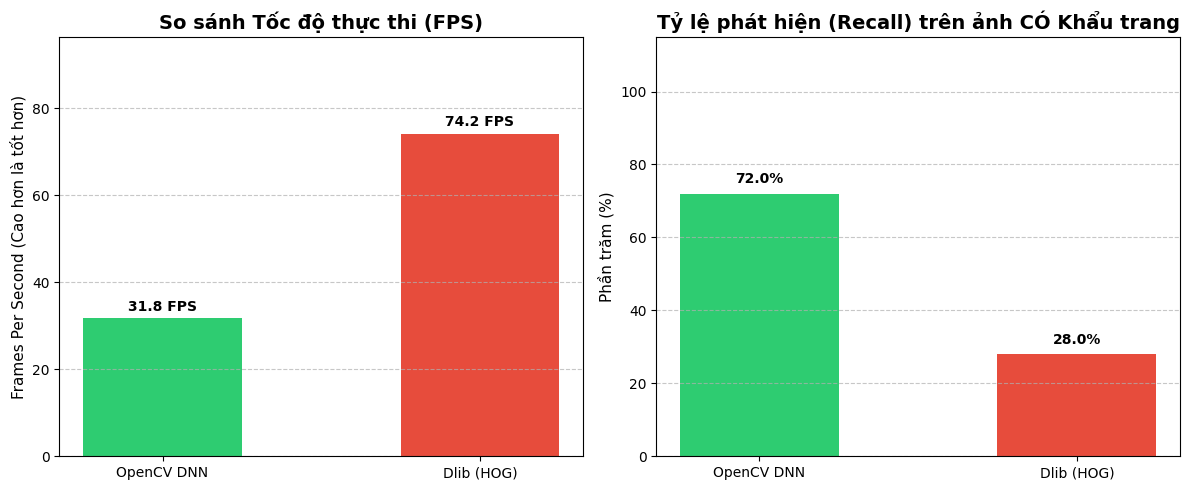

In [11]:
# Chạy test
fps_data, acc_mask_data = run_benchmark(all_images, all_labels)

# Cấu hình biểu đồ
methods = ['OpenCV DNN', 'Dlib (HOG)']
colors = ['#2ecc71', '#e74c3c'] # Xanh lá (DNN) và Đỏ (Dlib)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Biểu đồ 1: Tốc độ (FPS)
bars1 = ax[0].bar(methods, fps_data, color=colors, width=0.5)
ax[0].set_title('So sánh Tốc độ thực thi (FPS)', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Frames Per Second (Cao hơn là tốt hơn)', fontsize=11)
ax[0].set_ylim(0, max(fps_data) * 1.3)

for bar in bars1:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f} FPS', ha='center', va='bottom', fontweight='bold')

# Biểu đồ 2: Độ nhạy (Recall)
bars2 = ax[1].bar(methods, acc_mask_data, color=colors, width=0.5)
ax[1].set_title('Tỷ lệ phát hiện (Recall) trên ảnh CÓ Khẩu trang', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Phần trăm (%)', fontsize=11)
ax[1].set_ylim(0, 115)

for bar in bars2:
    yval = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

ax[0].grid(axis='y', linestyle='--', alpha=0.7)
ax[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Crop and resize

In [12]:
def crop_and_resize(img_bgr, bbox, size=(64, 64)):
    x, y, w, h = bbox
    face_roi = img_bgr[y:y+h, x:x+w]
    img_resize = cv2.resize(face_roi, size)
    return img_resize

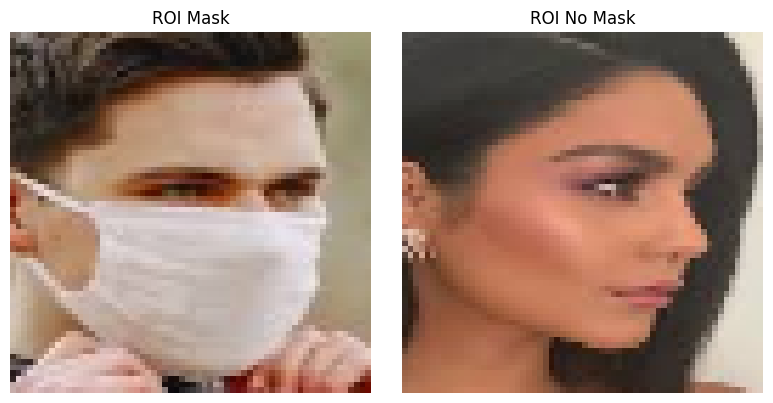

In [13]:
# Hiển thị thử Bước 3
roi_mask = crop_and_resize(sample_img_mask, bbox_mask_dnn)
roi_nomask = crop_and_resize(sample_img_nomask, bbox_nomask_dnn)

imgs = [roi_mask, roi_nomask]
titles = ["ROI Mask", "ROI No Mask"]

show_images(imgs, titles, cols=2)

# Trích xuất đặc trưng (HOG)

In [14]:
def extract_hog(gray, visualize=False):
    if visualize:
        feat, hog_img = hog(gray,
                            orientations=9,
                            pixels_per_cell=(8, 8),
                            cells_per_block=(2, 2),
                            visualize=True,
                            block_norm='L2-Hys')
        return feat, hog_img
    else:
        feat = hog(gray,
                   orientations=9,
                   pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2),
                   visualize=False,
                   block_norm='L2-Hys')
    return feat

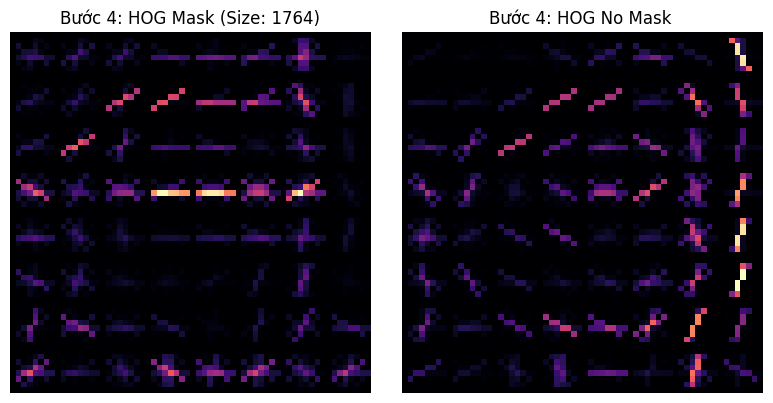

In [15]:
gray_mask = custom_preprocess(roi_mask)
gray_nomask = custom_preprocess(roi_nomask)
feat_mask, hog_img_mask = extract_hog(gray_mask, visualize=True)
feat_nomask, hog_img_nomask = extract_hog(gray_nomask, visualize=True)

imgs = [hog_img_mask, hog_img_nomask]
titles = [f"Bước 4: HOG Mask (Size: {feat_mask.shape[0]})", "Bước 4: HOG No Mask "]

show_images(imgs, titles, cols=2, cmap='magma')

# Phân loại

## Chuẩn bị dữ liệu

In [16]:
def robust_load_and_extract(dataset_path):
    hog_list, img_list, labels_list = [], [], []
    
    for label, cls_name in enumerate(['without_mask', 'with_mask']):
        folder_path = os.path.join(dataset_path, cls_name)
        count = 0
        
        print(f"Đang nạp và xử lý thư mục: {cls_name}")
        # Quét toàn bộ file trong thư mục
        for f in os.listdir(folder_path):
            img_path = os.path.join(folder_path, f)
            img = cv2.imread(img_path)
            if img is None: continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            # BƯỚC 1: Phát hiện khuôn mặt ngay trên ảnh gốc 
            # dùng DNN
            x, y, w, h = detect_face_dnn(img)
            # dùng Dlib
            # x, y, w, h = detect_face_hog(img) 
            
            # LOGIC LỌC NHIỄU 
            h_img, w_img = img.shape[:2]
            if w == w_img and h == h_img:
                if w_img >= 300 or h_img >= 300:
                    continue 
            
            try:
                
                # BƯỚC 2: Cắt và Resize
                roi_resized = crop_and_resize(img, (x, y, w, h), size=(64, 64))
                roi_resized_rgb = crop_and_resize(img_rgb, (x, y, w, h), size=(64, 64))
                
                # BƯỚC 3: Tiền xử lý chuyên sâu 
                roi_preprocessed = custom_preprocess(roi_resized)
                
                # BƯỚC 4: Rút trích HOG từ ảnh đã tiền xử lý 
                feat = extract_hog(roi_preprocessed)
                
                # Lưu lại cả 2 định dạng (HOG cho SVM, ảnh preprocessed cho CNN)
                hog_list.append(feat)
                img_list.append(roi_resized_rgb)
                labels_list.append(label)
                count += 1
            except Exception as e:
                pass
                    
        print(f"Đã thu thập được {count} mẫu hợp lệ từ lớp {cls_name}.")
        
    return np.array(hog_list), np.array(img_list), np.array(labels_list)

# 1. Thực thi Load Data
print("BẮT ĐẦU CHUẨN BỊ DỮ LIỆU CHO TOÀN BỘ DATASET")
X_hog, X_img, Y_labels = robust_load_and_extract(DATASET_PATH)

# 2. Chia tập Train / Test
X_train_hog, X_test_hog, X_train_img, X_test_img, y_train, y_test = train_test_split(
    X_hog, X_img, Y_labels, test_size=0.2, random_state=42
)

print("\nHOÀN TẤT CHUẨN BỊ DỮ LIỆU!")
print(f"Kích thước tập Train HOG: {X_train_hog.shape} | Train IMG: {X_train_img.shape}")

BẮT ĐẦU CHUẨN BỊ DỮ LIỆU CHO TOÀN BỘ DATASET
Đang nạp và xử lý thư mục: without_mask
Đã thu thập được 3827 mẫu hợp lệ từ lớp without_mask.
Đang nạp và xử lý thư mục: with_mask
Đã thu thập được 3543 mẫu hợp lệ từ lớp with_mask.

HOÀN TẤT CHUẨN BỊ DỮ LIỆU!
Kích thước tập Train HOG: (5896, 1764) | Train IMG: (5896, 64, 64, 3)


## Mô hình SVM

In [17]:
# 1. Khởi tạo và Train
print("Đang huấn luyện mô hình Linear SVM...")
svm_model = LinearSVC(max_iter=3000, random_state=42)
svm_model.fit(X_train_hog, y_train)

# 2. Dự đoán và đo thời gian (Runtime)
start_time = time.time()
y_pred_svm = svm_model.predict(X_test_hog)

# Lấy điểm số quyết định (khoảng cách tới ranh giới) để vẽ đồ thị PR Curve
y_scores_svm = svm_model.decision_function(X_test_hog) 
end_time = time.time()

# 3. Tính toán Runtime
total_runtime_svm = end_time - start_time
runtime_per_img_svm = total_runtime_svm / len(X_test_hog)

print("Huấn luyện và suy luận hoàn tất!")

Đang huấn luyện mô hình Linear SVM...
Huấn luyện và suy luận hoàn tất!


--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH LINEAR SVM ---
              precision    recall  f1-score   support

Without Mask       0.92      0.93      0.92       761
   With Mask       0.92      0.91      0.92       713

    accuracy                           0.92      1474
   macro avg       0.92      0.92      0.92      1474
weighted avg       0.92      0.92      0.92      1474


--- CÁC CHỈ SỐ BỔ SUNG ---
Runtime (Tổng trên tập Test): 0.0076 giây
Runtime (Trung bình 1 ảnh):   0.000005 giây (~193164 FPS)
Chỉ số IoU (Phân loại):       0.8460
Chỉ số MAE:                   0.0801


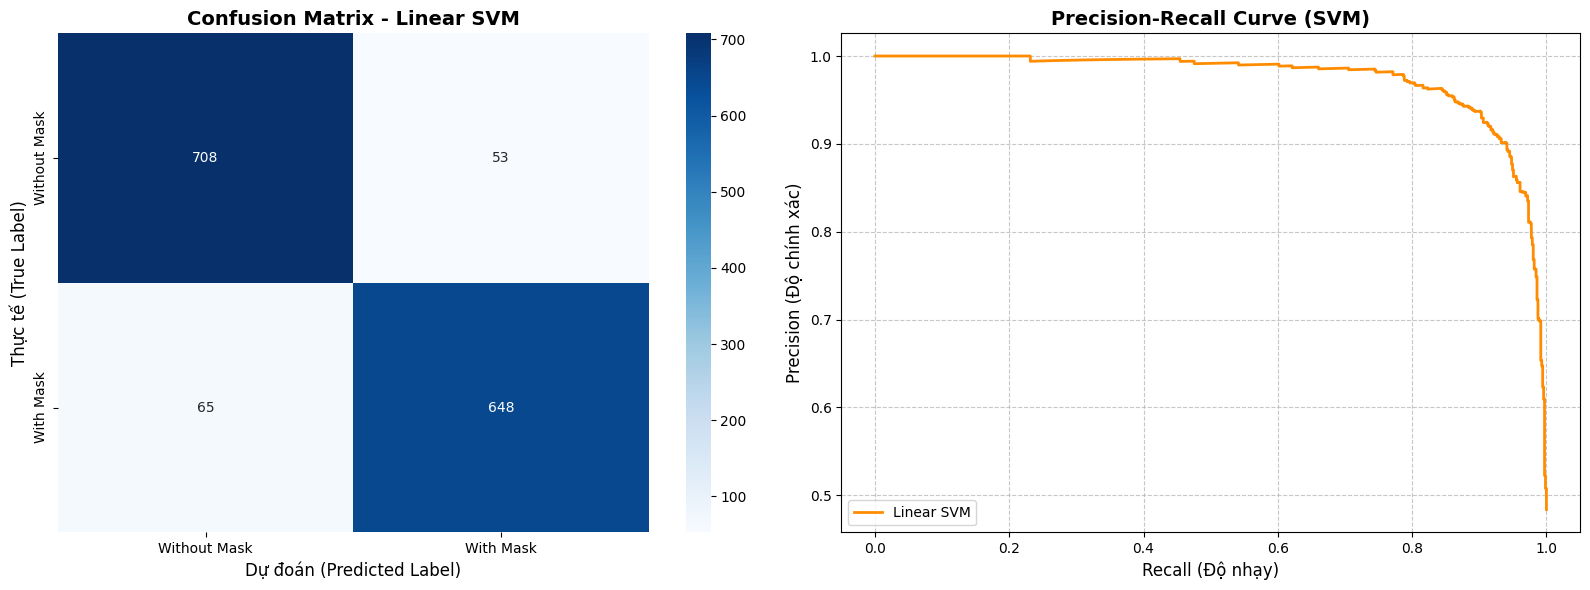

In [18]:
print("--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH LINEAR SVM ---")
print(classification_report(y_test, y_pred_svm, target_names=['Without Mask', 'With Mask']))

# 2. TÍNH TOÁN CÁC CHỈ SỐ BỔ SUNG
cm_svm = confusion_matrix(y_test, y_pred_svm)
tn, fp, fn, tp = cm_svm.ravel()

# Công thức tính IoU (Jaccard Index) và Dice (F1-Score)
iou_svm = tp / (tp + fp + fn)
mae_svm = mean_absolute_error(y_test, y_pred_svm)

print("\n--- CÁC CHỈ SỐ BỔ SUNG ---")
print(f"Runtime (Tổng trên tập Test): {total_runtime_svm:.4f} giây")
print(f"Runtime (Trung bình 1 ảnh):   {runtime_per_img_svm:.6f} giây (~{1/runtime_per_img_svm:.0f} FPS)")
print(f"Chỉ số IoU (Phân loại):       {iou_svm:.4f}")
print(f"Chỉ số MAE:                   {mae_svm:.4f}")

# 3. VẼ BIỂU ĐỒ (Confusion Matrix và PR Curve)
plt.figure(figsize=(16, 6))

# Subplot 1: Ma trận nhầm lẫn (Heatmap)
plt.subplot(1, 2, 1)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Without Mask', 'With Mask'], 
            yticklabels=['Without Mask', 'With Mask'])
plt.title('Confusion Matrix - Linear SVM', fontsize=14, fontweight='bold')
plt.xlabel('Dự đoán (Predicted Label)', fontsize=12)
plt.ylabel('Thực tế (True Label)', fontsize=12)

# Subplot 2: Precision-Recall Curve
plt.subplot(1, 2, 2)
precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_scores_svm)
plt.plot(recall_svm, precision_svm, color='darkorange', linewidth=2, label='Linear SVM')
plt.title('Precision-Recall Curve (SVM)', fontsize=14, fontweight='bold')
plt.xlabel('Recall (Độ nhạy)', fontsize=12)
plt.ylabel('Precision (Độ chính xác)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

## Mô hình Random Forest

In [19]:
# 1. Khởi tạo và Train
print("Đang huấn luyện mô hình Random Forest")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_hog, y_train)

# 2. Dự đoán và đo thời gian (Runtime)
start_time = time.time()
y_pred_rf = rf_model.predict(X_test_hog)

# Lấy xác suất để vẽ đồ thị PR Curve
y_scores_rf = rf_model.predict_proba(X_test_hog)[:, 1]
end_time = time.time()

# 3. Tính toán Runtime
total_runtime_rf = end_time - start_time
runtime_per_img_rf = total_runtime_rf / len(X_test_hog)

print("Huấn luyện và suy luận hoàn tất!")

Đang huấn luyện mô hình Random Forest
Huấn luyện và suy luận hoàn tất!


--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST ---
              precision    recall  f1-score   support

Without Mask       0.90      0.94      0.92       761
   With Mask       0.93      0.89      0.91       713

    accuracy                           0.91      1474
   macro avg       0.91      0.91      0.91      1474
weighted avg       0.91      0.91      0.91      1474


--- CÁC CHỈ SỐ BỔ SUNG ---
Runtime (Tổng trên tập Test): 0.1416 giây
Runtime (Trung bình 1 ảnh):   0.000096 giây (~10407 FPS)
Chỉ số IoU (Phân loại):       0.8331
Chỉ số MAE:                   0.0862


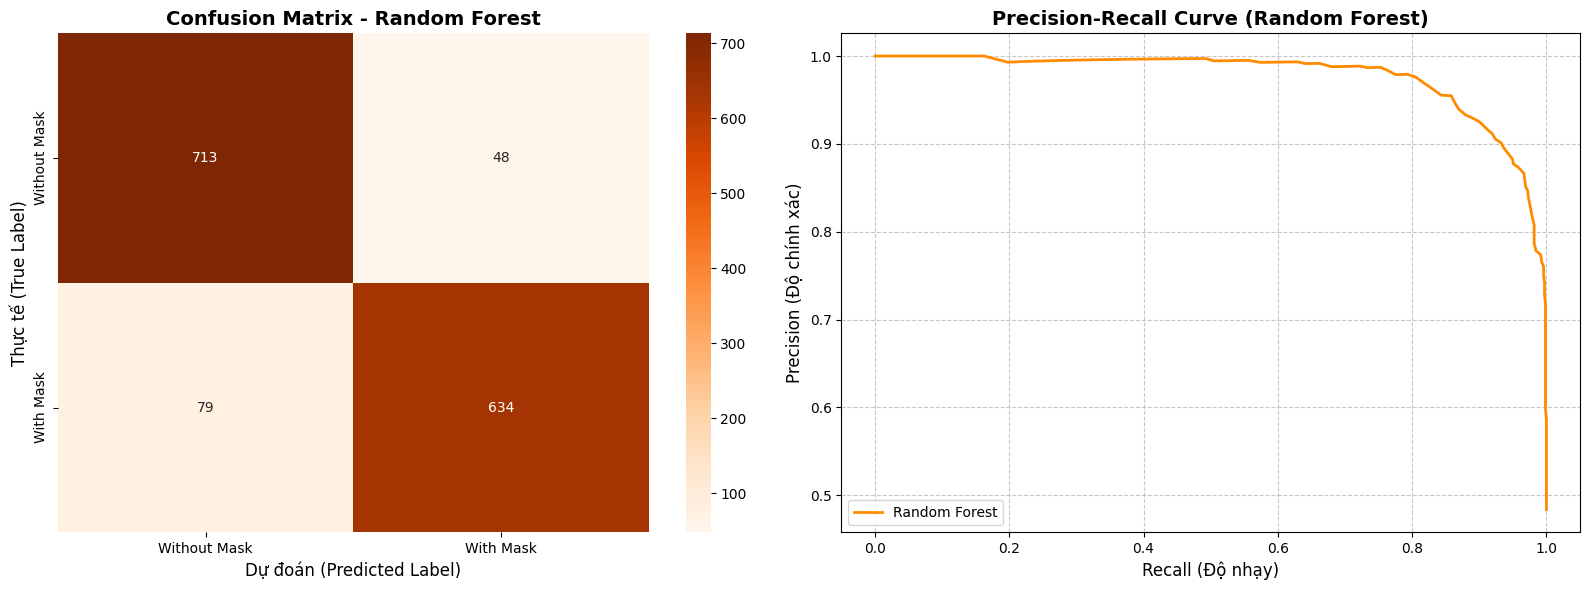

In [20]:
print("--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf, target_names=["Without Mask", "With Mask"]))

# 2. TÍNH TOÁN CÁC CHỈ SỐ BỔ SUNG
cm_rf = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm_rf.ravel()

iou_rf = tp / (tp + fp + fn)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

fps_rf = 1 / runtime_per_img_rf

print("\n--- CÁC CHỈ SỐ BỔ SUNG ---")
print(f"Runtime (Tổng trên tập Test): {total_runtime_rf:.4f} giây")
print(f"Runtime (Trung bình 1 ảnh):   {runtime_per_img_rf:.6f} giây (~{fps_rf:.0f} FPS)")
print(f"Chỉ số IoU (Phân loại):       {iou_rf:.4f}")
print(f"Chỉ số MAE:                   {mae_rf:.4f}")

# 3. VẼ BIỂU ĐỒ (Confusion Matrix và PR Curve)
plt.figure(figsize=(16, 6))

# Subplot 1: Ma trận nhầm lẫn (Heatmap)
plt.subplot(1, 2, 1)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Without Mask", "With Mask"],
            yticklabels=["Without Mask", "With Mask"])
plt.title("Confusion Matrix - Random Forest", fontsize=14, fontweight="bold")
plt.xlabel("Dự đoán (Predicted Label)", fontsize=12)
plt.ylabel("Thực tế (True Label)", fontsize=12)

# Subplot 2: Precision-Recall Curve
plt.subplot(1, 2, 2)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_scores_rf)
plt.plot(recall_rf, precision_rf, color="darkorange", linewidth=2, label="Random Forest")
plt.title("Precision-Recall Curve (Random Forest)", fontsize=14, fontweight="bold")
plt.xlabel("Recall (Độ nhạy)", fontsize=12)
plt.ylabel("Precision (Độ chính xác)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

## Mô hình CNN hạng nhẹ

In [21]:
# 1. Chuẩn bị dữ liệu (Ảnh màu RGB)
X_train_cnn = X_train_img.astype('float32') / 255.0
X_test_cnn = X_test_img.astype('float32') / 255.0

# 2. Xây dựng kiến trúc CNN 
cnn_model = Sequential([
    Input(shape=(64, 64, 3)),              
    
    Conv2D(16, (3, 3), activation='relu'), 
    MaxPooling2D(2, 2),
    
    Conv2D(32, (3, 3), activation='relu'), 
    MaxPooling2D(2, 2),
    
    Conv2D(64, (3, 3), activation='relu'), 
    MaxPooling2D(2, 2),
    
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') 
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Hiển thị cấu trúc mô hình
cnn_model.summary()

# 3. Huấn luyện 
print("Đang huấn luyện CNN...")
history = cnn_model.fit(
    X_train_cnn, y_train, 
    epochs=10,                
    batch_size=32, 
    validation_data=(X_test_cnn, y_test), 
    verbose=1
)

# 4. Dự đoán và đo thời gian (Runtime)
start_time_cnn = time.time()
y_pred_cnn_probs = cnn_model.predict(X_test_cnn, verbose=0)
end_time_cnn = time.time()

# Chuyển xác suất sang nhãn nhị phân (ngưỡng 0.5)
y_pred_cnn = (y_pred_cnn_probs > 0.5).astype("int32").flatten()

# Tính toán Runtime
total_runtime_cnn = end_time_cnn - start_time_cnn
runtime_per_img_cnn = total_runtime_cnn / len(X_test_cnn)

print("Hoàn tất quy trình huấn luyện và dự đoán.")

2026-05-24 02:29:19.290704: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,169 (668.63 KB)

 Trainable params: 171,169 (668.63 KB)

 Non-trainable params: 0 (0.00 B)

Đang huấn luyện CNN...
Epoch 1/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.8169 - loss: 0.3715 - val_accuracy: 0.9681 - val_loss: 0.1246
Epoch 2/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.9659 - loss: 0.0970 - val_accuracy: 0.8813 - val_loss: 0.2791
Epoch 3/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.9628 - loss: 0.1082 - val_accuracy: 0.9763 - val_loss: 0.0804
Epoch 4/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.9773 - loss: 0.0667 - val_accuracy: 0.9824 - val_loss: 0.0702
Epoch 5/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.9775 - loss: 0.0668 - val_accuracy: 0.9844 - val_loss: 0.0548
Epoch 6/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.9832 - loss: 0.0493 - val_accuracy: 0.9871 - val_loss: 0.0551
Epoch 7/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.9840 - loss: 0.0538 - val_accuracy: 0.9837 - val_loss: 0.0490
Epoch 8/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.9890 

--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH CNN HẠNG NHẸ ---
              precision    recall  f1-score   support

Without Mask       0.97      0.99      0.98       761
   With Mask       0.99      0.96      0.98       713

    accuracy                           0.98      1474
   macro avg       0.98      0.98      0.98      1474
weighted avg       0.98      0.98      0.98      1474


--- CÁC CHỈ SỐ BỔ SUNG ---
Runtime (Tổng trên tập Test): 0.7788 giây
Runtime (Trung bình 1 ảnh):   0.000528 giây (~1893 FPS)
Chỉ số IoU (Phân loại):       0.9554
Chỉ số MAE (Mean Abs Error):  0.0265


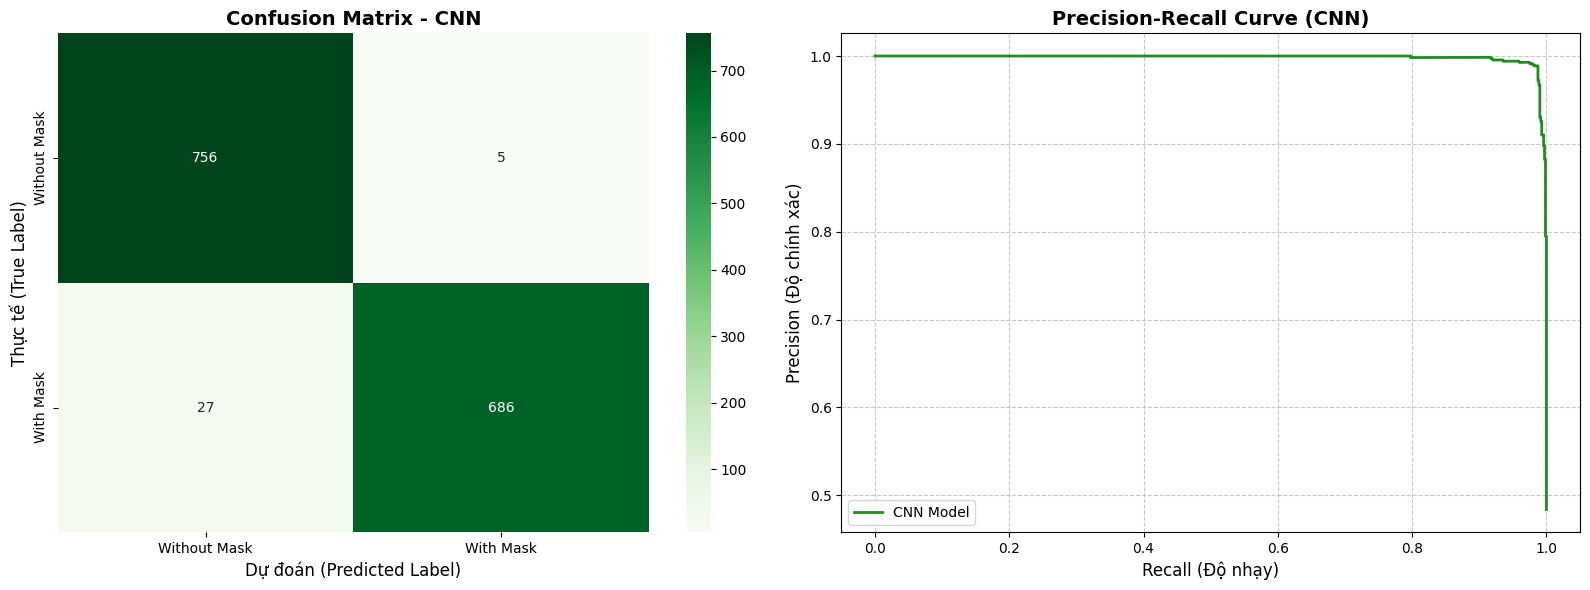

In [22]:
print("--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH CNN HẠNG NHẸ ---")
print(classification_report(y_test, y_pred_cnn, target_names=['Without Mask', 'With Mask']))

# 2. TÍNH TOÁN CÁC CHỈ SỐ BỔ SUNG
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
tn, fp, fn, tp = cm_cnn.ravel()

# IoU và Dice (F1-Score) cho phân loại
iou_cnn = tp / (tp + fp + fn)

# MAE tính trên xác suất dự đoán (độ lệch giữa xác suất và nhãn 0/1 thực tế)
mae_cnn = mean_absolute_error(y_test, y_pred_cnn_probs.flatten())

print("\n--- CÁC CHỈ SỐ BỔ SUNG ---")
print(f"Runtime (Tổng trên tập Test): {total_runtime_cnn:.4f} giây")
print(f"Runtime (Trung bình 1 ảnh):   {runtime_per_img_cnn:.6f} giây (~{1/runtime_per_img_cnn:.0f} FPS)")
print(f"Chỉ số IoU (Phân loại):       {iou_cnn:.4f}")
print(f"Chỉ số MAE (Mean Abs Error):  {mae_cnn:.4f}")

# 3. VẼ BIỂU ĐỒ TỔNG HỢP
plt.figure(figsize=(16, 6))

# Subplot 1: Ma trận nhầm lẫn
plt.subplot(1, 2, 1)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Without Mask', 'With Mask'], 
            yticklabels=['Without Mask', 'With Mask'])
plt.title('Confusion Matrix - CNN', fontsize=14, fontweight='bold')
plt.xlabel('Dự đoán (Predicted Label)', fontsize=12)
plt.ylabel('Thực tế (True Label)', fontsize=12)

# Subplot 2: Precision-Recall Curve
plt.subplot(1, 2, 2)
precision_cnn, recall_cnn, _ = precision_recall_curve(y_test, y_pred_cnn_probs)
plt.plot(recall_cnn, precision_cnn, color='forestgreen', linewidth=2, label='CNN Model')
plt.title('Precision-Recall Curve (CNN)', fontsize=14, fontweight='bold')
plt.xlabel('Recall (Độ nhạy)', fontsize=12)
plt.ylabel('Precision (Độ chính xác)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

# Trực quan hóa

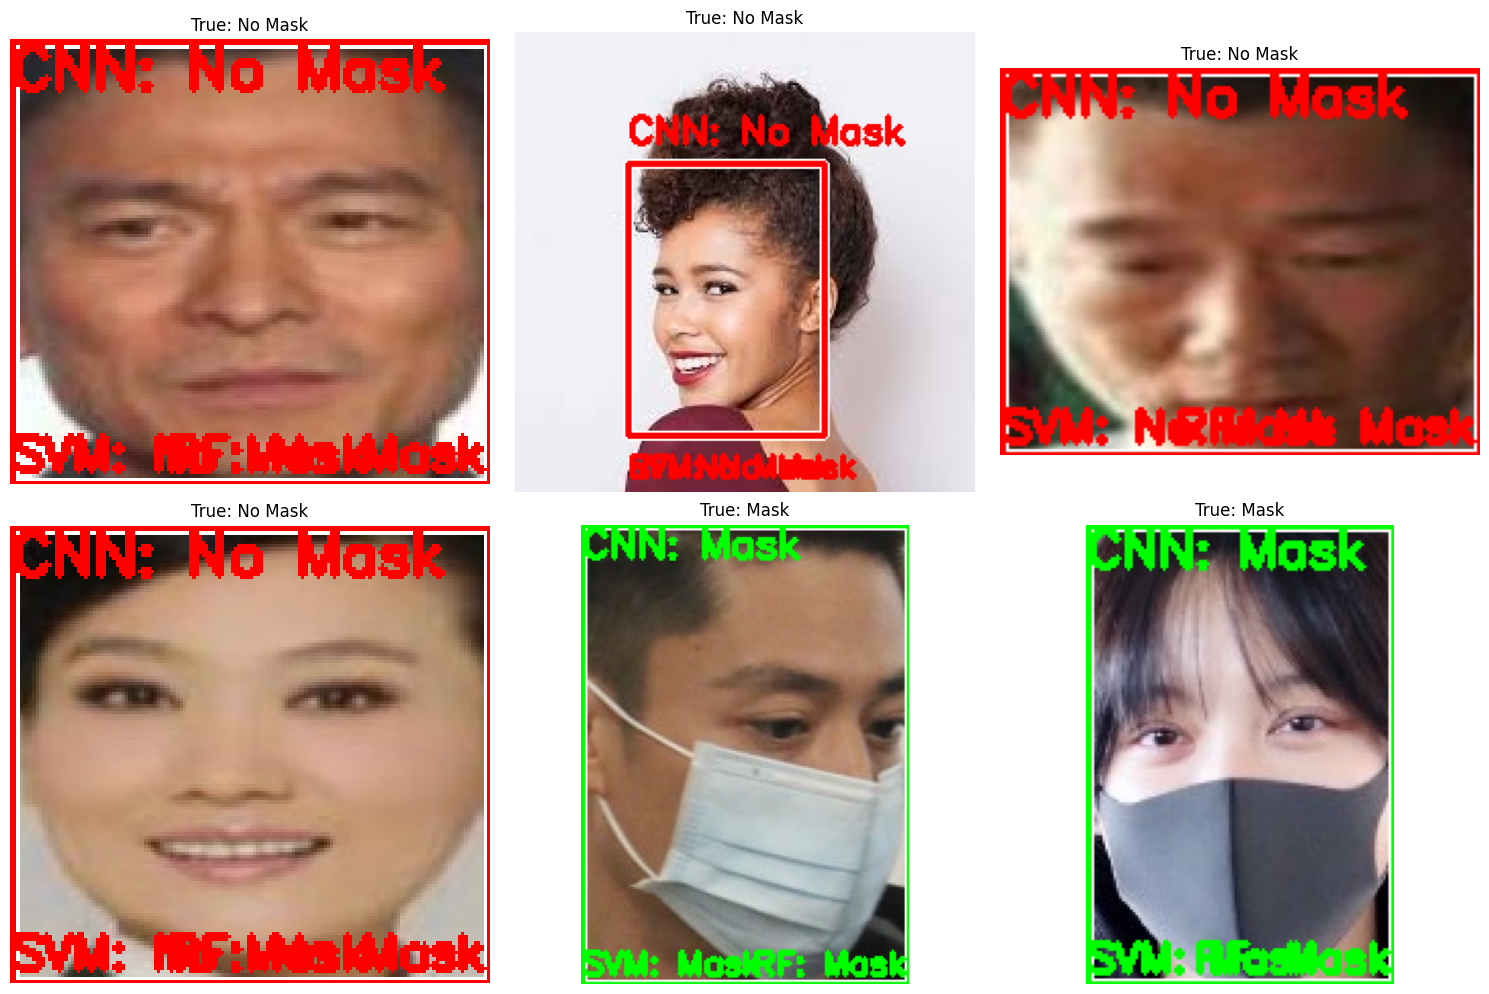

In [23]:
def visualize(dataset_path, num_samples=6):
    all_files = []
    for cls_name in ['without_mask', 'with_mask']:
        folder_path = os.path.join(dataset_path, cls_name)
        if os.path.exists(folder_path):
            files = [(os.path.join(folder_path, f), 1 if cls_name=='with_mask' else 0) for f in os.listdir(folder_path)]
            all_files.extend(files)
            
    if not all_files:
        print("Không tìm thấy dữ liệu!")
        return
        
    random_samples = random.sample(all_files, min(num_samples, len(all_files)))
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, (img_path, true_label) in enumerate(random_samples):
        img_bgr = cv2.imread(img_path)
        if img_bgr is None: continue
        
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        # Dùng hàm detect face
        x, y, w, h = detect_face_dnn(img_bgr)
        h_img, w_img = img_bgr.shape[:2]
        
        # Nếu tìm thấy mặt
        if not (w == w_img and h == h_img and (w_img >= 300 or h_img >= 300)):
            # Cắt ảnh khuôn mặt (hệ BGR) để dùng cho HOG
            roi_resized_bgr = crop_and_resize(img_bgr, (x, y, w, h), size=(64, 64))
            
            # Cắt ảnh khuôn mặt (hệ RGB) để dùng cho CNN màu
            roi_resized_rgb = crop_and_resize(img_rgb, (x, y, w, h), size=(64, 64))
            
            # 1. Luồng xử lý cho SVM & Random Forest (Dùng ảnh xám từ custom_preprocess)
            roi_prep = custom_preprocess(roi_resized_bgr)
            feat = extract_hog(roi_prep)
            
            # 2. Luồng xử lý cho CNN (Dùng thẳng ảnh màu, KHÔNG dùng expand_dims)
            # roi_resized_rgb đã có shape là (64, 64, 3)
            cnn_input = np.array([roi_resized_rgb]).astype('float32') / 255.0
            
            # --- DỰ ĐOÁN TỪ CÁC MODEL ---
            
            # CNN
            cnn_prob = cnn_model.predict(cnn_input, verbose=0)[0][0]
            cnn_pred = 1 if cnn_prob > 0.5 else 0
            cnn_c = (0, 255, 0) if cnn_pred == 1 else (255, 0, 0)
            label_cnn = "Mask" if cnn_pred == 1 else "No Mask"
            
            # SVM
            svm_pred = svm_model.predict([feat])[0]
            svm_c = (0, 255, 0) if svm_pred == 1 else (255, 0, 0)
            label_svm = "Mask" if svm_pred == 1 else "No Mask"
            
            # Random Forest (RF)
            rf_pred = rf_model.predict([feat])[0]
            rf_c = (0, 255, 0) if rf_pred == 1 else (255, 0, 0)
            label_rf = "Mask" if rf_pred == 1 else "No Mask"
            
            # --- VẼ KHUNG VÀ GHI CHÚ LÊN ẢNH ---
            
            # Vẽ viền khung mặt (viền trắng lót dưới, viền chính lấy màu theo CNN làm mốc)
            cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (255, 255, 255), 4)
            cv2.rectangle(img_rgb, (x, y), (x+w, y+h), cnn_c, 2)
            
            # A. In CNN ở trên cùng
            cv2.putText(img_rgb, f"CNN: {label_cnn}", (x, max(15, y-10)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, cnn_c, 2)
            
            # B. In SVM ở góc dưới bên trái
            cv2.putText(img_rgb, f"SVM: {label_svm}", (x, min(img_rgb.shape[0]-5, y+h+20)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, svm_c, 2)
            
            # C. In Random Forest ở góc dưới bên phải
            text_rf = f"RF: {label_rf}"
            # Lấy kích thước text để căn lề phải cho chuẩn
            (tw, th), _ = cv2.getTextSize(text_rf, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)
            rf_x = max(x, x + w - tw) # Tính tọa độ X sao cho chữ vừa khít góc phải
            
            cv2.putText(img_rgb, text_rf, (rf_x, min(img_rgb.shape[0]-5, y+h+20)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, rf_c, 2)
            
        true_text = "Mask" if true_label == 1 else "No Mask"
        axes[i].imshow(img_rgb)
        axes[i].set_title(f"True: {true_text}", fontsize=12)
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

# Gọi hàm chạy thử
visualize(DATASET_PATH, 6)

========== THỐNG KÊ TRÊN TẬP TEST ==========
Tổng số ảnh có sự bất đồng giữa các mô hình: 193 ảnh.
  -> CNN đoán ĐÚNG: 170 ảnh (88.1%)
  -> SVM đoán ĐÚNG: 84 ảnh (43.5%)
  -> RF đoán ĐÚNG:  75 ảnh (38.9%)
  => KẾT LUẬN: Khi gặp ca khó, CNN xử lý tốt nhất!

Đang tìm kiếm ngẫu nhiên 5 ảnh từ thư mục gốc để hiển thị Bounding Box...


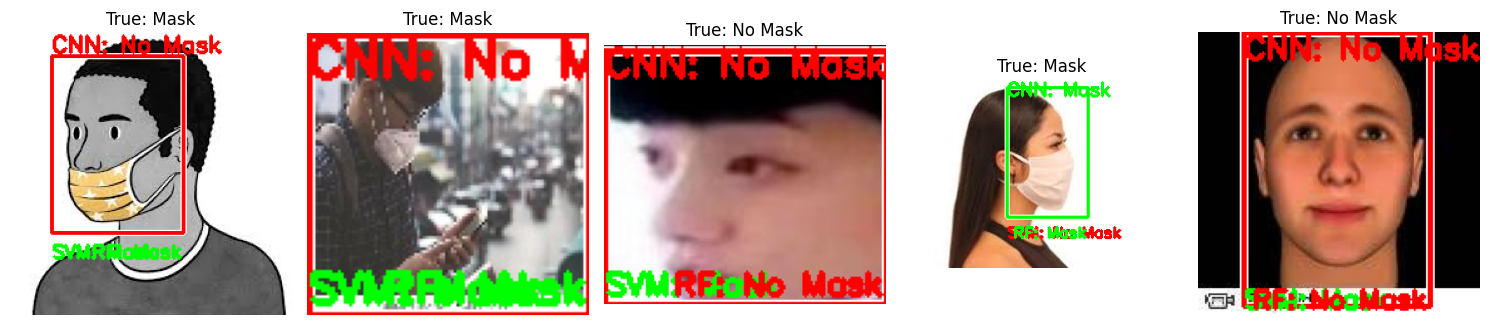

In [24]:
def find_and_plot_mismatches(dataset_path, num_show=5):

    mismatch_mask = ~((y_pred_cnn == y_pred_svm) & (y_pred_svm == y_pred_rf))
    total_mismatches_test = np.sum(mismatch_mask)
    
    # Trong các trường hợp "ca khó" đó, đếm xem ai là người khớp với nhãn thực tế (y_test)
    cnn_correct_count = np.sum((y_pred_cnn == y_test) & mismatch_mask)
    svm_correct_count = np.sum((y_pred_svm == y_test) & mismatch_mask)
    rf_correct_count  = np.sum((y_pred_rf == y_test) & mismatch_mask)
    
    print(f"========== THỐNG KÊ TRÊN TẬP TEST ==========")
    print(f"Tổng số ảnh có sự bất đồng giữa các mô hình: {total_mismatches_test} ảnh.")
    
    if total_mismatches_test > 0:
        cnn_win_rate = (cnn_correct_count / total_mismatches_test) * 100
        svm_win_rate = (svm_correct_count / total_mismatches_test) * 100
        rf_win_rate  = (rf_correct_count / total_mismatches_test) * 100
        
        print(f"  -> CNN đoán ĐÚNG: {cnn_correct_count} ảnh ({cnn_win_rate:.1f}%)")
        print(f"  -> SVM đoán ĐÚNG: {svm_correct_count} ảnh ({svm_win_rate:.1f}%)")
        print(f"  -> RF đoán ĐÚNG:  {rf_correct_count} ảnh ({rf_win_rate:.1f}%)")
        
        # Đánh giá kết luận linh hoạt dựa trên mô hình cao điểm nhất
        max_correct = max(cnn_correct_count, svm_correct_count, rf_correct_count)
        winners = []
        if cnn_correct_count == max_correct: winners.append("CNN")
        if svm_correct_count == max_correct: winners.append("SVM")
        if rf_correct_count == max_correct:  winners.append("Random Forest")
        
        if len(winners) == 1:
            print(f"  => KẾT LUẬN: Khi gặp ca khó, {winners[0]} xử lý tốt nhất!")
        else:
            print(f"  => KẾT LUẬN: Khi gặp ca khó, {' và '.join(winners)} có khả năng xử lý ngang nhau và tốt nhất!")
            
    print(f"============================================\n")
    
    # ========================================================
    # PHẦN 2: TÌM VÀ VẼ ẢNH MINH HỌA
    # ========================================================
    if total_mismatches_test == 0:
        print("Không có sự khác biệt nào giữa 3 mô hình để hiển thị ảnh!")
        return

    print(f"Đang tìm kiếm ngẫu nhiên {num_show} ảnh từ thư mục gốc để hiển thị Bounding Box...")
    
    all_files = []
    for cls_name in ['without_mask', 'with_mask']:
        folder_path = os.path.join(dataset_path, cls_name)
        if os.path.exists(folder_path):
            files = [(os.path.join(folder_path, f), 1 if cls_name=='with_mask' else 0) for f in os.listdir(folder_path)]
            all_files.extend(files)
            
    random.shuffle(all_files)
    mismatched_images = []
    
    for img_path, true_label in all_files:
        if len(mismatched_images) >= num_show:
            break
            
        img_bgr = cv2.imread(img_path)
        if img_bgr is None: continue
        
        # Chuyển sẵn ảnh sang RGB để dùng vẽ và đưa vào CNN
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        x, y, w, h = detect_face_dnn(img_bgr) 
        h_img, w_img = img_bgr.shape[:2]
        
        # Bỏ qua nếu không tìm thấy mặt
        if w == w_img and h == h_img and (w_img >= 300 or h_img >= 300):
            continue
            
        # Cắt khuôn mặt cho 2 luồng riêng biệt
        roi_resized_bgr = crop_and_resize(img_bgr, (x, y, w, h), size=(64, 64))
        roi_resized_rgb = crop_and_resize(img_rgb, (x, y, w, h), size=(64, 64))
        
        # 1. Rút trích HOG từ ảnh xám (Dùng chung cho SVM và RF)
        roi_prep = custom_preprocess(roi_resized_bgr)
        feat = extract_hog(roi_prep)
        
        # 2. Dự đoán SVM & RF
        svm_pred = svm_model.predict([feat])[0]
        rf_pred  = rf_model.predict([feat])[0]
        
        # 3. Dự đoán CNN (Dùng ảnh màu RGB, KHÔNG dùng expand_dims)
        cnn_input = np.array([roi_resized_rgb]).astype('float32') / 255.0
        cnn_prob = cnn_model.predict(cnn_input, verbose=0)[0][0]
        cnn_pred = 1 if cnn_prob > 0.5 else 0
        
        # Lưu lại nếu có BẤT KỲ sự khác biệt nào giữa 3 mô hình
        if not (svm_pred == cnn_pred == rf_pred):
            mismatched_images.append({
                'img_rgb': img_rgb,  # Lưu thẳng ảnh RGB để vẽ luôn
                'bbox': (x, y, w, h),
                'svm': svm_pred,
                'cnn': cnn_pred,
                'rf': rf_pred,
                'true': true_label
            })
            
    if not mismatched_images:
        print("Không quét được ảnh nào dự đoán khác nhau (do thuật toán cắt mặt bỏ qua)!")
        return
        
    # Xử lý an toàn grid hiển thị ảnh của Matplotlib
    num_to_show = len(mismatched_images)
    fig, axes = plt.subplots(1, num_to_show, figsize=(15, 4))
    # Đảm bảo axes luôn là một mảng để có thể lặp qua, ngay cả khi chỉ có 1 ảnh
    axes = np.atleast_1d(axes) 
    
    for i, data in enumerate(mismatched_images):
        img_draw = data['img_rgb'].copy() # Copy để không đè lên ảnh gốc
        x, y, w, h = data['bbox']
        
        svm_c = (0, 255, 0) if data['svm'] == 1 else (255, 0, 0)
        cnn_c = (0, 255, 0) if data['cnn'] == 1 else (255, 0, 0)
        rf_c  = (0, 255, 0) if data['rf']  == 1 else (255, 0, 0)
        
        cv2.rectangle(img_draw, (x, y), (x+w, y+h), (255, 255, 255), 4)
        cv2.rectangle(img_draw, (x, y), (x+w, y+h), cnn_c, 2)
        
        label_cnn = "Mask" if data['cnn'] == 1 else "No Mask"
        label_svm = "Mask" if data['svm'] == 1 else "No Mask"
        label_rf  = "Mask" if data['rf']  == 1 else "No Mask"
        
        # A. In CNN trên cùng
        cv2.putText(img_draw, f"CNN: {label_cnn}", (x, max(15, y-10)), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, cnn_c, 2)
        
        # B. In SVM góc dưới trái
        cv2.putText(img_draw, f"SVM: {label_svm}", (x, min(img_draw.shape[0]-5, y+h+20)), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, svm_c, 2)
        
        # C. In RF góc dưới phải
        text_rf = f"RF: {label_rf}"
        (tw, th), _ = cv2.getTextSize(text_rf, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)
        rf_x = max(x, x + w - tw)
        cv2.putText(img_draw, text_rf, (rf_x, min(img_draw.shape[0]-5, y+h+20)), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, rf_c, 2)
        
        true_text = "Mask" if data['true'] == 1 else "No Mask"
        axes[i].imshow(img_draw)
        axes[i].set_title(f"True: {true_text}", fontsize=12)
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

# Gọi hàm thực thi
find_and_plot_mismatches(DATASET_PATH, 5)

# Mở rộng (Xử lý Video Streaming / Webcam)

In [25]:
def process_webcam_stream(classifier_type="CNN"):
    """
    classifier_type: Chọn "CNN" hoặc "SVM"
    """
    # Mở Webcam mặc định (0). Bạn có thể thay bằng file video VD: 'test_video.mp4'
    cap = cv2.VideoCapture("/kaggle/input/datasets/manhhoanggia/video-test11/video_test.mp4") 
    
    if not cap.isOpened():
        print("Không thể kết nối đến Camera hoặc không tìm thấy file video!")
        return
        
    # ================== PHẦN THÊM MỚI: KHỞI TẠO LƯU VIDEO ==================
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps_video = int(cap.get(cv2.CAP_PROP_FPS))
    if fps_video == 0: fps_video = 30 # Đề phòng lỗi không lấy được FPS
    
    output_path = "output_video.mp4"
    fourcc = cv2.VideoWriter_fourcc(*'mp4v') # Định dạng mp4
    out = cv2.VideoWriter(output_path, fourcc, fps_video, (width, height))
    # =======================================================================
    
    print(f"Đang khởi động Camera với mô hình {classifier_type}...")
    print("Đang xử lý và lưu video nền. Vui lòng đợi...")
    
    prev_time = time.time()
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        # Lấy FPS
        curr_time = time.time()
        fps = 1 / (curr_time - prev_time + 1e-6) # Cộng thêm 1e-6 để tránh lỗi chia cho 0
        prev_time = curr_time
        
        # Tiền xử lý để tìm mặt (giả định dùng hệ BGR nguyên bản cho hàm detect)
        x, y, w, h = detect_face_dnn(frame)
        h_img, w_img = frame.shape[:2]
        
        # Nếu tìm thấy mặt hợp lệ
        if not (w == w_img and h == h_img and (w_img >= 300 or h_img >= 300)):
            # Cắt mặt ra và đưa về 64x64 (Lúc này vẫn là BGR)
            roi_resized = crop_and_resize(frame, (x, y, w, h), size=(64, 64))
            
            # CHIA LUỒNG XỬ LÝ DỮ LIỆU TÙY THEO MODEL
            if classifier_type == "CNN":
                # CNN cần ảnh màu RGB (64, 64, 3)
                roi_rgb = cv2.cvtColor(roi_resized, cv2.COLOR_BGR2RGB)
                # Đưa vào array và chuẩn hóa, BỎ HẲN expand_dims
                cnn_input = np.array([roi_rgb]).astype('float32') / 255.0
                
                prob = cnn_model.predict(cnn_input, verbose=0)[0][0]
                pred = 1 if prob > 0.5 else 0
                
            else:
                # SVM/RF cần ảnh xám và rút trích HOG
                roi_prep = custom_preprocess(roi_resized)
                feat = extract_hog(roi_prep)
                
                pred = svm_model.predict([feat])[0]
                
            color = (0, 255, 0) if pred == 1 else (0, 0, 255) # Xanh (Đeo), Đỏ (Không)
            label = "Mask" if pred == 1 else "No Mask"
            
            cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)
            cv2.putText(frame, f"{classifier_type}: {label}", (x, max(15, y-10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
            
        # Hiển thị FPS trên góc màn hình
        cv2.putText(frame, f"FPS: {int(fps)}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)
        
        # ================== PHẦN THÊM MỚI: GHI FRAME VÀO FILE ==================
        out.write(frame)
        # =======================================================================
        
        # LƯU Ý KAGGLE: Phải ẩn 3 dòng này đi để Kernel không bị chết!
        # cv2.imshow('Face Mask Detection - Real-time', frame)
        # if cv2.waitKey(1) & 0xFF == ord('q'):
        #     break
            
    cap.release()
    out.release() # <--- PHẦN THÊM MỚI: Nhớ đóng file output
    cv2.destroyAllWindows()
    print(f"Đã đóng luồng Camera thành công. Video kết quả được lưu tại: {output_path}")

# Hướng dẫn: Bỏ dấu '#' ở dòng dưới và chạy Cell này để mở Webcam nhận diện theo thời gian thực.
# Quá trình này sẽ sử dụng Camera máy tính của bạn.
process_webcam_stream(classifier_type="CNN")

Đang khởi động Camera với mô hình CNN...
Đang xử lý và lưu video nền. Vui lòng đợi...
Đã đóng luồng Camera thành công. Video kết quả được lưu tại: output_video.mp4
